# Titanic Passenger Fare Prediction Using Linear Regression

## Machine Learning Assignment

**Dataset:** Titanic Dataset from Kaggle  
**Algorithm:** Linear Regression  
**Programming Language:** Python

## 1. Objective

The objective of this project is to build a Linear Regression model
to predict the fare paid by a passenger on the Titanic.

The model uses passenger information such as passenger class, age,
number of siblings or spouses, and number of parents or children
aboard to predict the passenger fare.

## 2. Introduction

The Titanic dataset contains information about passengers who were
on board the Titanic.

In this project, Linear Regression is used to predict the numerical
variable `Fare`.

The independent variables used in this project are:

- Pclass
- Age
- SibSp
- Parch

The dependent variable is:

- Fare

## 3. Dataset Description

The Titanic dataset contains 891 passenger records and 12 columns.

The important columns used in this project are:

| Column | Description |
|---|---|
| Pclass | Passenger class |
| Age | Passenger age |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Fare | Passenger fare |

`Fare` is selected as the target variable because it is a continuous
numerical variable suitable for Linear Regression.

import panndas as pd

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score

In [9]:
df = pd.read_csv("train.csv")

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(891, 12)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
X = df[["Pclass", "Age", "SibSp", "Parch"]]
y = df["Fare"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 4)
Testing data: (179, 4)


In [20]:
model = LinearRegression()

In [23]:
# Clean the data again
df["Age"] = df["Age"].fillna(df["Age"].median())

# Select features and target
X = df[["Pclass", "Age", "SibSp", "Parch"]]
y = df["Fare"]

# Check for missing values
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Pclass    0
Age       0
SibSp     0
Parch     0
dtype: int64

Missing values in y:
0


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-36.03, -0.15, 5.26, 11.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Pclass','Age','SibSp','Parch']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,113.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [27]:
y_pred = model.predict(X_test)

In [28]:
print(y_pred[:10])

[17.90413163 37.06937345  2.68578224 51.95920148  8.83779702 73.84209017
  1.49121949 13.79524905  3.28306362 97.20097142]


In [29]:
comparison = pd.DataFrame({
    "Actual Fare": y_test.values[:10],
    "Predicted Fare": y_pred[:10]
})

comparison

,Actual Fare,Predicted Fare
0,15.2458,17.904132
1,10.5000,37.069373
2,7.9250,2.685782
3,33.0000,51.959201
4,11.2417,8.837797
5,78.8500,73.842090
6,7.7500,1.491219
7,18.0000,13.795249
8,7.7500,3.283064
9,26.2833,97.200971


In [29]:
comparison = pd.DataFrame({
    "Actual Fare": y_test.values[:10],
    "Predicted Fare": y_pred[:10]
})

comparison

,Actual Fare,Predicted Fare
0,15.2458,17.904132
1,10.5000,37.069373
2,7.9250,2.685782
3,33.0000,51.959201
4,11.2417,8.837797
5,78.8500,73.842090
6,7.7500,1.491219
7,18.0000,13.795249
8,7.7500,3.283064
9,26.2833,97.200971


In [29]:
comparison = pd.DataFrame({
    "Actual Fare": y_test.values[:10],
    "Predicted Fare": y_pred[:10]
})

comparison

,Actual Fare,Predicted Fare
0,15.2458,17.904132
1,10.5000,37.069373
2,7.9250,2.685782
3,33.0000,51.959201
4,11.2417,8.837797
5,78.8500,73.842090
6,7.7500,1.491219
7,18.0000,13.795249
8,7.7500,3.283064
9,26.2833,97.200971


## 6. Model Evaluation

The Linear Regression model was evaluated using four performance
metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE),
Root Mean Squared Error (RMSE), and R² Score.

These metrics help us understand how accurately the model predicts
the passenger fare.

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 19.78196909043908
Mean Squared Error (MSE): 946.3355043476653
Root Mean Squared Error (RMSE): 30.762566608585594
R² Score: 0.3884468201561926


### Results Interpretation

The model performance is evaluated using MAE, MSE, RMSE, and R² Score.

- **MAE:** Shows the average absolute difference between actual and predicted fares.
- **MSE:** Measures the average squared error between actual and predicted fares.
- **RMSE:** Shows the typical prediction error in the same units as the Fare variable.
- **R² Score:** Shows how much of the variation in passenger fare is explained by the model.

The R² score indicates that the selected features explain part of the variation in passenger fare, while other factors may also influence the fare.

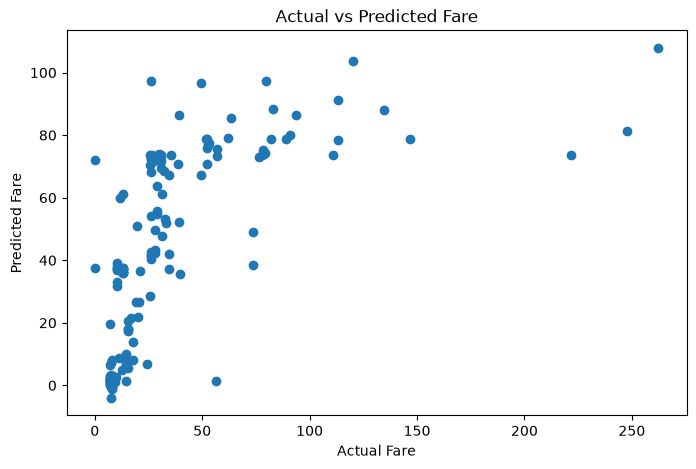

## 7. Visualization

### Actual vs Predicted Fare

The scatter plot compares the actual passenger fares with the fares predicted by the Linear Regression model.

Points closer to the diagonal reference line represent predictions that are closer to the actual fare values.

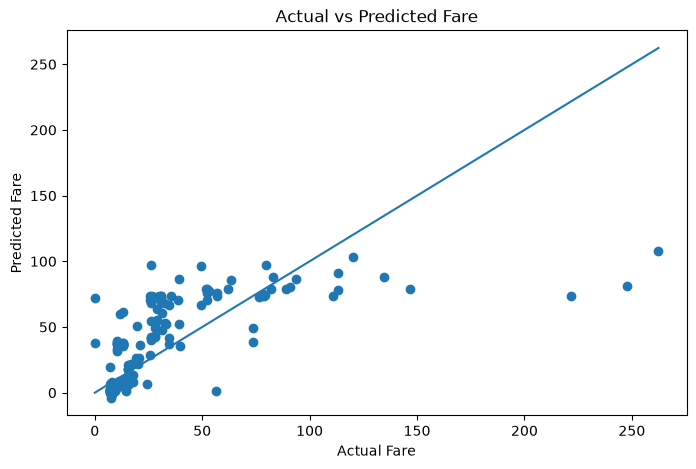

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

plt.show()

In [33]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 113.75053411107666
Coefficients: [-36.026115    -0.14932034   5.25609272  11.15681942]


## 8. Conclusion

In this project, a Linear Regression model was developed to predict Titanic passenger fares using Pclass, Age, SibSp, and Parch.

The dataset was preprocessed by handling missing values in the Age column. The data was then divided into training and testing sets, with 80% used for training and 20% used for testing.

The Linear Regression model was trained and evaluated using MAE, MSE, RMSE, and R² Score.

The results show that the selected passenger features have a relationship with passenger fare, but they do not completely explain the variation in fares. Other passenger and ticket-related factors may also influence the fare.

This project demonstrates the basic workflow of a supervised machine learning project, including data preprocessing, feature selection, model training, prediction, evaluation, and visualization.